# Pokémon Type Strength Analysis and Visualization

This notebook analyzes and visualizes the average total base stats of Pokémon grouped by their primary type. The goal of this analysis is to identify which Pokémon types tend to have stronger overall statistics based on official game data.

The dataset was filtered to include only default-form Pokémon, excluding legendary and mythical Pokémon, to create a more balanced comparison across types. Additionally, types with fewer than five Pokémon were removed to reduce the impact of small sample sizes on the averages.

Using Python libraries such as Pandas, Matplotlib, and Seaborn, the notebook processes the data and generates a horizontal bar chart visualization that highlights differences in average base stats between Pokémon types.

This visualization helps communicate trends in Pokémon type strength in a clear and visually accessible format.

### Importing Libraries and Loading the Dataset

This cell imports the libraries needed for data analysis and visualization:

- `pandas` is used for reading and manipulating tabular data.
- `matplotlib.pyplot` provides plotting functionality and figure customization.
- `seaborn` is used to create cleaner and more visually appealing statistical graphics.

The CSV file `type_strength_results.csv` is then loaded into a DataFrame named `viz_df`. This dataset contains the processed Pokémon type statistics used to generate the visualization.

In [1]:
# Import libraries for data handling and plotting
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Creating the Bar Chart Visualization

This cell prepares and visualizes the Pokémon type statistics using a horizontal bar chart.

Key design decisions:
- The data is sorted in ascending order, so the strongest types appear near the top of the chart, making comparisons easier to read.
- A horizontal bar chart was chosen because type names are categorical labels and are more readable vertically aligned on the y-axis.
- The `viridis` color palette was used to give each type a distinct color while maintaining visual consistency and accessibility.
- The x-axis starts at 350 instead of 0 to visually emphasize the relatively small differences between average base stats across types.
- Value labels were added directly to each bar so viewers can quickly identify exact averages without estimating from the axis.
- Gridlines and `sns.despine()` were used to improve readability while reducing unnecessary visual clutter.
- A figure note was added below the chart to document the filtering conditions applied to the dataset, improving transparency and reproducibility of the analysis.
- Save as PNG.

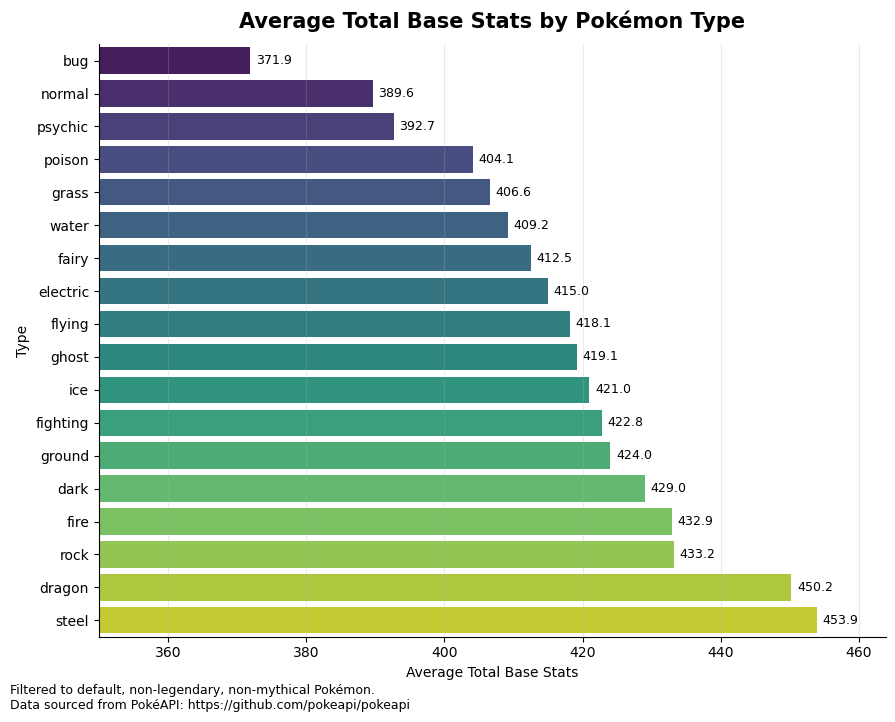

In [2]:
viz_df = pd.read_csv("type_strength_results.csv")

# Sort so highest appears at top
viz_df = viz_df.sort_values("avg_total_base_stats", ascending = True)

plt.figure(figsize = (9, 7))

# Create a colorful palette with one color per type
palette = sns.color_palette("viridis", n_colors = len(viz_df))

ax = sns.barplot(
    data = viz_df,
    x = "avg_total_base_stats",
    y = "type_name",
    hue = "type_name",
    palette = palette,
    legend = False
)

# Shrink bar length visually by zooming x-axis
ax.set_xlim(350, viz_df["avg_total_base_stats"].max() + 10)

ax.set_title(
    "Average Total Base Stats by Pokémon Type",
    fontsize = 15,
    weight = "bold",
    pad = 12
)

ax.set_xlabel("Average Total Base Stats")
ax.set_ylabel("Type")

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt = "%.1f", padding = 4, fontsize = 9)

# Cleaner style
sns.despine()
ax.grid(axis = "x", alpha = 0.25)
ax.grid(axis = "y", visible = False)

plt.figtext(0.01, -0.02,
            "Filtered to default, non-legendary, non-mythical Pokémon. \n"
            "Data sourced from PokéAPI: https://github.com/pokeapi/pokeapi",
            ha = "left", fontsize = 9)
plt.tight_layout()

# Save the chart as a PNG file
plt.savefig(os.path.join("output", "pokemon_type_avg_base_stats.png"), dpi = 300, bbox_inches = "tight")
plt.show()